# **DATASET 1**

In [1]:
#load the dataset
import pandas as pd

df = pd.read_csv("CrimesOnWomenData.csv")
df = df.drop("Unnamed: 0", axis=1)

df.head()

,State,Year,Rape,K&A (Kidnapping and Abduction cases),Dowry Deaths,Assault against Women,Assault against Modesty of Women,Domestic Violence,Women Trafficking
0,ANDHRA PRADESH,2001,871,765,420,3544,2271,5791,7
1,ARUNACHAL PRADESH,2001,33,55,0,78,3,11,0
2,ASSAM,2001,817,1070,59,850,4,1248,0
3,BIHAR,2001,888,518,859,562,21,1558,83
4,CHHATTISGARH,2001,959,171,70,1763,161,840,0


In [2]:
#We convert raw crime data into a prediction problem.
df["Total_Crime"] = df.iloc[:, 2:].sum(axis=1)

df["Crime_Level"] = (df["Total_Crime"] > df["Total_Crime"].median()).astype(int)

In [3]:
#Encode Categorical Data
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["State"] = le.fit_transform(df["State"])

In [4]:
#define features and target
X = df.drop(["Total_Crime", "Crime_Level"], axis=1)
y = df["Crime_Level"]

In [5]:
#Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
#Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [7]:
#Train Models (Baseline)
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

gnb = GaussianNB()
mlp = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)

gnb.fit(X_train, y_train)
mlp.fit(X_train, y_train)

MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)

In [8]:
#Evaluate Baseline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate(y_true, y_pred, name):
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1-score:", f1_score(y_true, y_pred))

y_pred_gnb = gnb.predict(X_test)
y_pred_mlp = mlp.predict(X_test)

evaluate(y_test, y_pred_gnb, "GNB (Before SHAP)")
evaluate(y_test, y_pred_mlp, "MLP (Before SHAP)")


GNB (Before SHAP)
Accuracy: 0.9594594594594594
Precision: 0.9117647058823529
Recall: 1.0
F1-score: 0.9538461538461539

MLP (Before SHAP)
Accuracy: 0.9864864864864865
Precision: 1.0
Recall: 0.967741935483871
F1-score: 0.9836065573770492


Measured model performance. This is our baseline.

**Apply SHAP (Feature importance)**

In [9]:
!pip install shap
import shap

explainer = shap.KernelExplainer(mlp.predict, X_train[:100])
shap_values = explainer.shap_values(X_train[:100])

  0%|          | 0/100 [00:00<?, ?it/s]

Used SHAP to understand model decisions. Applied on MLP.

In [10]:
#Calculate Feature Importance
import numpy as np

if isinstance(shap_values, list):
    shap_values = shap_values[0]

importance = np.abs(shap_values).mean(axis=0)

#Computed average SHAP values. Got importance of each feature

In [11]:
#Select Top Features
N = 5
top_indices = np.argsort(importance)[-N:]

X_train_new = X_train[:, top_indices]
X_test_new = X_test[:, top_indices]

In [12]:
#Retrain Models
gnb.fit(X_train_new, y_train)
mlp.fit(X_train_new, y_train)

y_pred_gnb_new = gnb.predict(X_test_new)
y_pred_mlp_new = mlp.predict(X_test_new)

evaluate(y_test, y_pred_gnb_new, "GNB (After SHAP)")
evaluate(y_test, y_pred_mlp_new, "MLP (After SHAP)")


GNB (After SHAP)
Accuracy: 0.9459459459459459
Precision: 0.8857142857142857
Recall: 1.0
F1-score: 0.9393939393939394

MLP (After SHAP)
Accuracy: 0.9932432432432432
Precision: 1.0
Recall: 0.9838709677419355
F1-score: 0.991869918699187


**PLOTS**

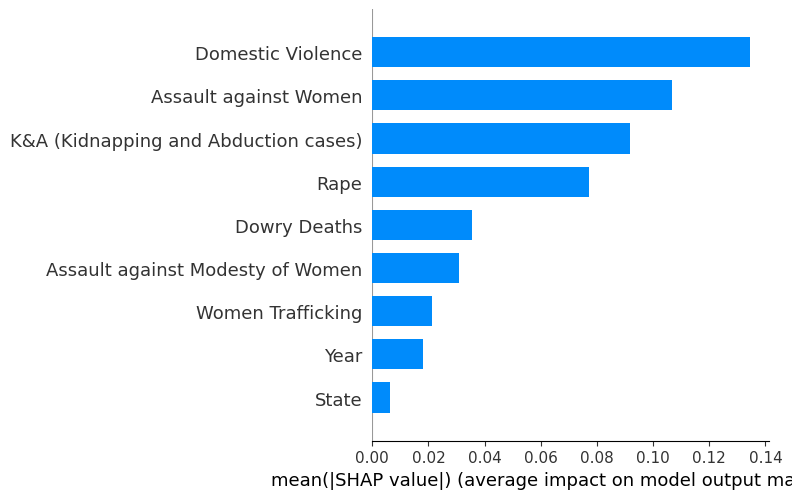

In [13]:
feature_names = X.columns
X_train_df = pd.DataFrame(X_train, columns=feature_names)

shap.summary_plot(shap_values, X_train_df[:100], plot_type="bar")

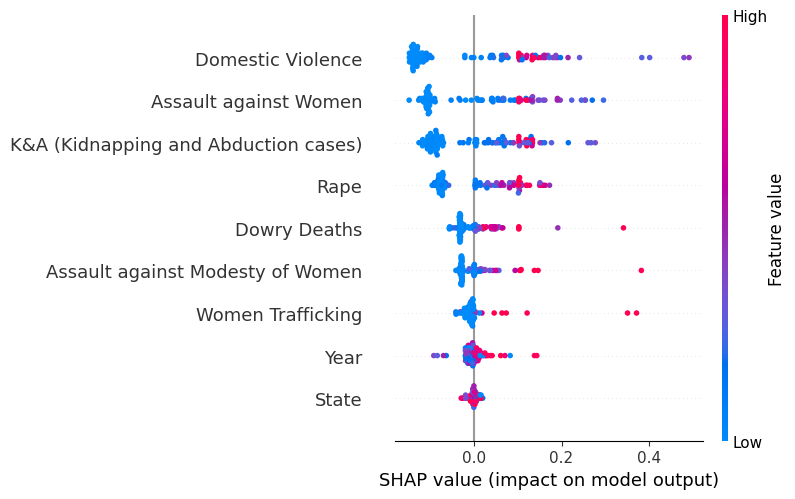

In [14]:
#Summary Plot
shap.summary_plot(shap_values, X_train_df[:100])

# **DATASET 2**

In [15]:
#load dataset
import pandas as pd

df = pd.read_csv("crime_dataset_india.csv")
df.head()

/usr/local/lib/python3.12/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,Report Number,Date Reported,Date of Occurrence,Time of Occurrence,City,Crime Code,Crime Description,Victim Age,Victim Gender,Weapon Used,Crime Domain,Police Deployed,Case Closed,Date Case Closed
0,1,02-01-2020 00:00,01-01-2020 00:00,01-01-2020 01:11,Ahmedabad,576,IDENTITY THEFT,16,M,Blunt Object,Violent Crime,13,No,NaN
1,2,01-01-2020 19:00,01-01-2020 01:00,01-01-2020 06:26,Chennai,128,HOMICIDE,37,M,Poison,Other Crime,9,No,NaN
2,3,02-01-2020 05:00,01-01-2020 02:00,01-01-2020 14:30,Ludhiana,271,KIDNAPPING,48,F,Blunt Object,Other Crime,15,No,NaN
3,4,01-01-2020 05:00,01-01-2020 03:00,01-01-2020 14:46,Pune,170,BURGLARY,49,F,Firearm,Other Crime,1,Yes,29-04-2020 05:00
4,5,01-01-2020 21:00,01-01-2020 04:00,01-01-2020 16:51,Pune,421,VANDALISM,30,F,Other,Other Crime,18,Yes,08-01-2020 21:00


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40160 entries, 0 to 40159
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Report Number       40160 non-null  int64 
 1   Date Reported       40160 non-null  object
 2   Date of Occurrence  40160 non-null  object
 3   Time of Occurrence  40160 non-null  object
 4   City                40160 non-null  object
 5   Crime Code          40160 non-null  int64 
 6   Crime Description   40160 non-null  object
 7   Victim Age          40160 non-null  int64 
 8   Victim Gender       40160 non-null  object
 9   Weapon Used         34370 non-null  object
 10  Crime Domain        40160 non-null  object
 11  Police Deployed     40160 non-null  int64 
 12  Case Closed         40160 non-null  object
 13  Date Case Closed    20062 non-null  object
dtypes: int64(4), object(10)
memory usage: 4.3+ MB


In [17]:
#predict whether the case will be closed or not
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["Case Closed"] = le.fit_transform(df["Case Closed"])

y = df["Case Closed"]
X = df.drop("Case Closed", axis=1)

In [18]:
#Data Cleaning + Preprocessing

df["Date Reported"] = pd.to_datetime(df["Date Reported"], dayfirst=True, format='mixed')
df["Date of Occurrence"] = pd.to_datetime(df["Date of Occurrence"], dayfirst=True, format='mixed')

# Extract useful parts
df["Report_Year"] = df["Date Reported"].dt.year
df["Report_Month"] = df["Date Reported"].dt.month

df["Occur_Year"] = df["Date of Occurrence"].dt.year
df["Occur_Month"] = df["Date of Occurrence"].dt.month

In [19]:
#drop original date columns
df = df.drop(
    ["Date Reported", "Date of Occurrence", "Date Case Closed"],
    axis=1,
    errors="ignore",
)

In [20]:
#Handle Time Column
if 'Time of Occurrence' in df.columns:
    df["Time of Occurrence"] = pd.to_datetime(df["Time of Occurrence"], dayfirst=True, format='mixed')

    df["Hour"] = df["Time of Occurrence"].dt.hour

    df = df.drop("Time of Occurrence", axis=1)

In [21]:
#Handle Missing Values
df["Weapon Used"] = df["Weapon Used"].fillna("Unknown")

In [22]:
#Encode Categorical Columns
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = [
    "City", "Crime Description", "Victim Gender",
    "Weapon Used", "Crime Domain"
]

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [23]:
#Drop Unnecessary Columns
df = df.drop("Report Number", axis=1)

In [24]:
#Define Features (X) and Target (y)
y = df["Case Closed"]
X = df.drop("Case Closed", axis=1)

In [25]:
#Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [26]:
#Scaling (important for MLP)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [27]:
#Train Models (Baseline)
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

gnb = GaussianNB()
mlp = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)

gnb.fit(X_train, y_train)
mlp.fit(X_train, y_train)

MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)

In [28]:
#Evaluate (Baseline)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate(y_true, y_pred, name):
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1-score:", f1_score(y_true, y_pred))

y_pred_gnb = gnb.predict(X_test)
y_pred_mlp = mlp.predict(X_test)

evaluate(y_test, y_pred_gnb, "GNB (Before SHAP)")
evaluate(y_test, y_pred_mlp, "MLP (Before SHAP)")


GNB (Before SHAP)
Accuracy: 0.49290338645418325
Precision: 0.4892619106393483
Recall: 0.49724034119417965
F1-score: 0.4932188627597362

MLP (Before SHAP)
Accuracy: 0.5013695219123506
Precision: 0.4973125884016973
Recall: 0.4410436527847466
F1-score: 0.46749102512963703


**Apply SHAP**

In [29]:
!pip install shap
import shap
import numpy as np

In [30]:
#Create SHAP Explainer
explainer = shap.KernelExplainer(mlp.predict, X_train[:100])

In [31]:
#Compute SHAP values
shap_values = explainer.shap_values(X_train[:100])

  0%|          | 0/100 [00:00<?, ?it/s]

In [32]:
#Fix shape issue
if isinstance(shap_values, list):
    shap_values = shap_values[0]

In [33]:
#Feature Importance
importance = np.abs(shap_values).mean(axis=0)

In [34]:
#Select Top N Features
N = 5  # you can try 5 or 10

top_indices = np.argsort(importance)[-N:]

X_train_new = X_train[:, top_indices]
X_test_new = X_test[:, top_indices]

In [35]:
#Retrain models
gnb.fit(X_train_new, y_train)
mlp.fit(X_train_new, y_train)

y_pred_gnb_new = gnb.predict(X_test_new)
y_pred_mlp_new = mlp.predict(X_test_new)

evaluate(y_test, y_pred_gnb_new, "GNB (After SHAP)")
evaluate(y_test, y_pred_mlp_new, "MLP (After SHAP)")


GNB (After SHAP)
Accuracy: 0.4940239043824701
Precision: 0.4892205638474295
Recall: 0.4440541896638234
F1-score: 0.4655444502893214

MLP (After SHAP)
Accuracy: 0.5054780876494024
Precision: 0.5016294227188082
Recall: 0.5406422478675363
F1-score: 0.520405699106496


**PLOTS**

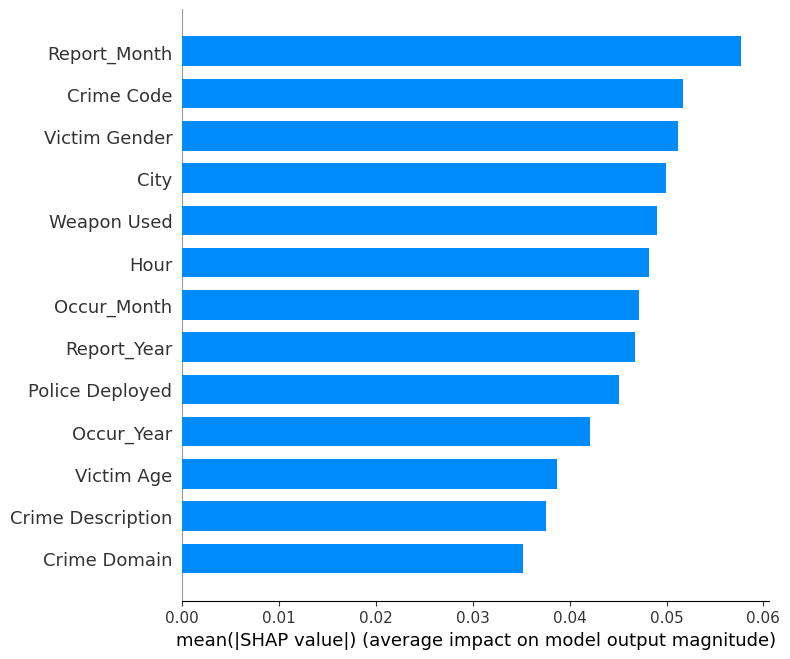

In [36]:
#bar plot
import matplotlib.pyplot as plt

X_train_df = pd.DataFrame(X_train, columns=X.columns)

shap.summary_plot(shap_values, X_train_df[:100], plot_type="bar")

plt.show()

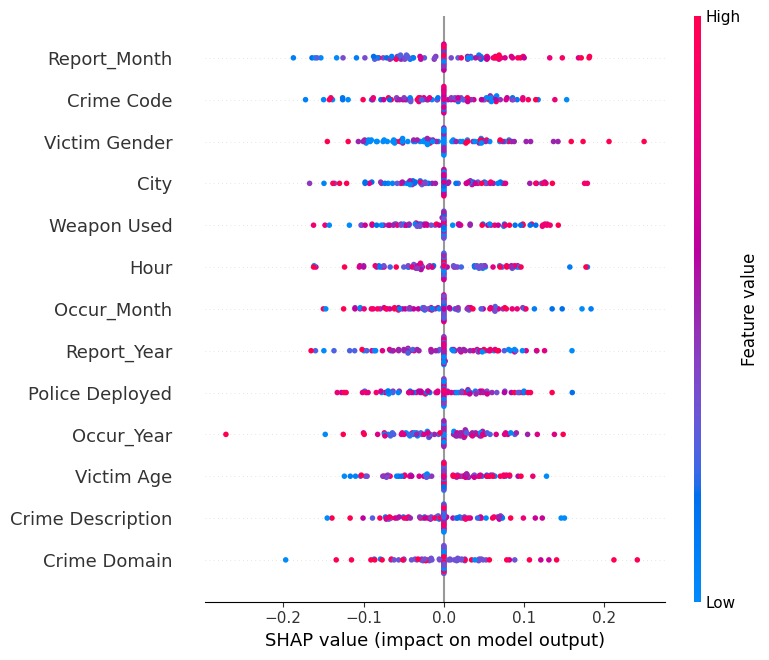

In [37]:
#summary plot
import matplotlib.pyplot as plt

# Convert back to DataFrame (important for feature names)
X_train_df = pd.DataFrame(X_train, columns=X.columns)

# Summary plot
shap.summary_plot(shap_values, X_train_df[:100])

plt.show()

**FINAL COMPARISON FOR BOTH DATASETS**

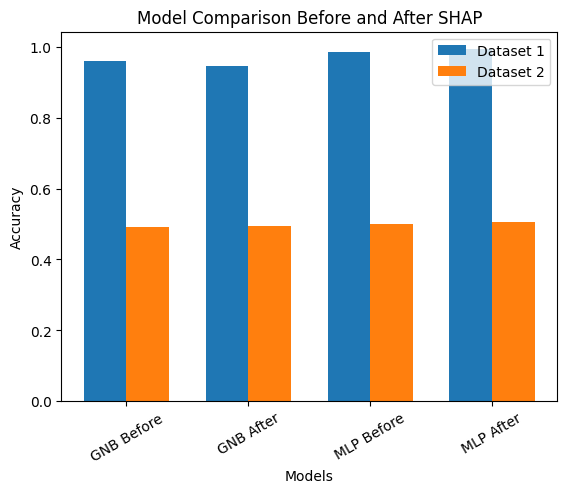

In [39]:
import matplotlib.pyplot as plt
import numpy as np

# Dataset 1 (Accuracy)
ds1 = [
    0.9594594594594594,   # GNB Before
    0.9459459459459459,   # GNB After
    0.9864864864864865,   # MLP Before
    0.9932432432432432    # MLP After
]

# Dataset 2 (Accuracy)
ds2 = [
    0.49290338645418325,  # GNB Before
    0.4940239043824701,   # GNB After
    0.5013695219123506,   # MLP Before
    0.5054780876494024    # MLP After
]

labels = ["GNB Before", "GNB After", "MLP Before", "MLP After"]

x = np.arange(len(labels))
width = 0.35

plt.figure()

# Side-by-side bars
plt.bar(x - width/2, ds1, width, label="Dataset 1")
plt.bar(x + width/2, ds2, width, label="Dataset 2")

plt.xticks(x, labels, rotation=30)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Comparison Before and After SHAP")
plt.legend()

plt.show()

In [49]:
import pandas as pd

# Create data
data = [
    ["Dataset 1", "GNB", "Before SHAP", 0.959, 0.912, 1.000, 0.954, "Baseline"],
    ["Dataset 1", "GNB", "After SHAP", 0.946, 0.886, 1.000, 0.939, "Slight Decrease"],
    ["Dataset 1", "MLP", "Before SHAP", 0.986, 1.000, 0.968, 0.984, "Baseline"],
    ["Dataset 1", "MLP", "After SHAP", 0.993, 1.000, 0.984, 0.992, "Improved"],
    ["Dataset 2", "GNB", "Before SHAP", 0.493, 0.489, 0.497, 0.493, "Baseline"],
    ["Dataset 2", "GNB", "After SHAP", 0.494, 0.489, 0.444, 0.466, "Slight Change"],
    ["Dataset 2", "MLP", "Before SHAP", 0.501, 0.497, 0.441, 0.467, "Baseline"],
    ["Dataset 2", "MLP", "After SHAP", 0.505, 0.502, 0.541, 0.520, "Improved"]
]

# Create DataFrame
columns = ["Dataset", "Model", "Stage", "Accuracy", "Precision", "Recall", "F1-score", "SHAP Effect"]

df_results = pd.DataFrame(data, columns=columns)

# Display table
df_results.style.background_gradient(cmap="Blues")

,Dataset,Model,Stage,Accuracy,Precision,Recall,F1-score,SHAP Effect
0,Dataset 1,GNB,Before SHAP,0.959000,0.912000,1.000000,0.954000,Baseline
1,Dataset 1,GNB,After SHAP,0.946000,0.886000,1.000000,0.939000,Slight Decrease
2,Dataset 1,MLP,Before SHAP,0.986000,1.000000,0.968000,0.984000,Baseline
3,Dataset 1,MLP,After SHAP,0.993000,1.000000,0.984000,0.992000,Improved
4,Dataset 2,GNB,Before SHAP,0.493000,0.489000,0.497000,0.493000,Baseline
5,Dataset 2,GNB,After SHAP,0.494000,0.489000,0.444000,0.466000,Slight Change
6,Dataset 2,MLP,Before SHAP,0.501000,0.497000,0.441000,0.467000,Baseline
7,Dataset 2,MLP,After SHAP,0.505000,0.502000,0.541000,0.520000,Improved
